# Canadian Retail Sales Forecasting & Macro Driver Analysis

## 1. Project Objective
I used this project to refresh my Python and data analysis skills. The question is whether recent sales patterns can help predict next month's Canadian retail sales, and whether adding a few macroeconomic variables helps.

This is a small learning project using public data. I compare a simple baseline with linear regression, Ridge, and Random Forest, then look at what worked and what did not.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Environment ready!")
print(pd.__version__)
print(np.__version__)

Environment ready!
2.0.3
1.24.4


## 2. Data Sources

Only public national data are used. Statistics Canada: [retail 20-10-0067-01](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=2010006701), [seasonally adjusted CPI 18-10-0006-01](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1810000601), [labour force 14-10-0287-01](https://www150.statcan.gc.ca/t1/tbl1/en/tv.action?pid=1410028701). Bank of Canada Valet: V39079 and FXUSDCAD.

The analysis ends June 2026 to retain the original experiment window. Local public-data caches are reused; deleting them refreshes from official sources, which may revise historical values.


In [2]:
from pathlib import Path
import json
import io
import zipfile
import requests

# Find the data folders from the project root or notebooks folder.
PROJECT_ROOT = Path.cwd() if (Path.cwd() / "notebooks").is_dir() else Path.cwd().parent
RAW = PROJECT_ROOT / "data" / "raw"
PROCESSED = PROJECT_ROOT / "data" / "processed"
RAW.mkdir(parents=True, exist_ok=True)
PROCESSED.mkdir(parents=True, exist_ok=True)
ANALYSIS_END = "2026-06"

# Download missing public data files.
for table, filename, start in [
    ("20100067", "retail_sales_raw.csv", "2017-01"),
    ("18100006", "cpi_raw.csv", "1992-01"),
    ("14100287", "unemployment_raw.csv", "1976-01"),
]:
    destination = RAW / filename
    if not destination.exists():
        response = requests.get(f"https://www150.statcan.gc.ca/n1/tbl/csv/{table}-eng.zip", timeout=180)
        response.raise_for_status()
        with zipfile.ZipFile(io.BytesIO(response.content)) as archive:
            parts = []
            # Read the larger tables in chunks to limit memory use.
            for chunk in pd.read_csv(archive.open(table + ".csv"), chunksize=100000, low_memory=False):
                keep = (chunk["GEO"] == "Canada") & chunk["REF_DATE"].between(start, ANALYSIS_END)
                parts.append(chunk.loc[keep])
            pd.concat(parts, ignore_index=True).to_csv(destination, index=False)

def public_valet(series):
    cache = RAW / (series + ".json")
    if not cache.exists():
        response = requests.get(
            f"https://www.bankofcanada.ca/valet/observations/{series}/json",
            params={"start_date": "2017-01-01", "end_date": "2026-06-30"}, timeout=60,
        )
        response.raise_for_status()
        cache.write_text(json.dumps(response.json()), encoding="utf-8")
    return json.loads(cache.read_text(encoding="utf-8"))


## 3. Data Cleaning and Preparation


In [3]:
df = pd.read_csv(RAW / "retail_sales_raw.csv", low_memory=False)


In [4]:
df.head()


,REF_DATE,GEO,DGUID,North American Industry Classification System (NAICS),"Sales, price and volume",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2017-01,Canada,2021A000011124,Retail trade [44-45],Retail sales in current prices,Dollars,81,millions,6,v1446870151,1.1.1,50417.0,NaN,NaN,NaN,0
1,2017-01,Canada,2021A000011124,Retail trade [44-45],Retail sales Chained Fisher volume index (scal...,Dollars,81,millions,6,v1446870181,1.1.2,50138.0,NaN,NaN,NaN,0
2,2017-01,Canada,2021A000011124,Retail trade [44-45],Fisher Chained Price Index (scaled to equal 10...,Index,160,millions,6,v1446870182,1.1.3,100.6,NaN,NaN,NaN,1
3,2017-01,Canada,2021A000011124,Retail trade [44-45],Retail sales at 2017 constant prices (Unchaine...,Dollars,81,millions,6,v1446870183,1.1.4,50138.0,NaN,NaN,NaN,0
4,2017-01,Canada,2021A000011124,Motor vehicle and parts dealers [441],Retail sales in current prices,Dollars,81,millions,6,v1446870152,1.2.1,13562.0,NaN,NaN,NaN,0


In [5]:
df.columns.tolist()

['REF_DATE',
 'GEO',
 'DGUID',
 'North American Industry Classification System (NAICS)',
 'Sales, price and volume',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'SYMBOL',
 'TERMINATED',
 'DECIMALS']

In [6]:
df.size

112416

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7026 entries, 0 to 7025
Data columns (total 16 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   REF_DATE                                               7026 non-null   object 
 1   GEO                                                    7026 non-null   object 
 2   DGUID                                                  7026 non-null   object 
 3   North American Industry Classification System (NAICS)  7026 non-null   object 
 4   Sales, price and volume                                7026 non-null   object 
 5   UOM                                                    7026 non-null   object 
 6   UOM_ID                                                 7026 non-null   int64  
 7   SCALAR_FACTOR                                          7026 non-null   object 
 8   SCALAR_ID                                       

In [8]:
df["Sales, price and volume"].unique()

array(['Retail sales in current prices',
       'Retail sales Chained Fisher volume index (scaled to equal 100 in 2017)',
       'Fisher Chained Price Index (scaled to equal 100 in 2017)',
       'Retail sales at 2017 constant prices (Unchained Laspeyres Index)'],
      dtype=object)

In [9]:
df["North American Industry Classification System (NAICS)"].unique()

array(['Retail trade [44-45]', 'Motor vehicle and parts dealers [441]',
       'Automobile dealers [4411]', 'New car dealers [44111]',
       'Used car dealers [44112]', 'Other motor vehicle dealers [4412]',
       'Automotive parts, accessories and tire retailers [4413]',
       'Building material and garden equipment and supplies dealers [444]',
       'Food and beverage retailers [445]',
       'Grocery and convenience retailers [4451]',
       'Supermarkets and other grocery retailers (except convenience retailers)  [44511]',
       'Convenience retailers and vending machine operators [44513]',
       'Specialty food retailers [4452]',
       'Beer, wine and liquor retailers [4453]',
       'Furniture, home furnishings, electronics and appliances retailers [449]',
       'Furniture, floor covering, window treatment and other home furnishings retailers [4491]',
       'Furniture retailers [44911]',
       'Floor covering, window treatment and other home furnishing retailers [44912]'

In [10]:
df["REF_DATE"].min(), df["REF_DATE"].max()

('2017-01', '2026-06')

In [11]:
retail = df[
    (df["GEO"] == "Canada") &
    (df["North American Industry Classification System (NAICS)"] == "Retail trade [44-45]") &
    (df["Sales, price and volume"] == "Retail sales in current prices")
].copy()

In [12]:
retail.head()

,REF_DATE,GEO,DGUID,North American Industry Classification System (NAICS),"Sales, price and volume",UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2017-01,Canada,2021A000011124,Retail trade [44-45],Retail sales in current prices,Dollars,81,millions,6,v1446870151,1.1.1,50417.0,NaN,NaN,NaN,0
60,2017-02,Canada,2021A000011124,Retail trade [44-45],Retail sales in current prices,Dollars,81,millions,6,v1446870151,1.1.1,49863.0,NaN,NaN,NaN,0
120,2017-03,Canada,2021A000011124,Retail trade [44-45],Retail sales in current prices,Dollars,81,millions,6,v1446870151,1.1.1,49937.0,NaN,NaN,NaN,0
180,2017-04,Canada,2021A000011124,Retail trade [44-45],Retail sales in current prices,Dollars,81,millions,6,v1446870151,1.1.1,50827.0,NaN,NaN,NaN,0
240,2017-05,Canada,2021A000011124,Retail trade [44-45],Retail sales in current prices,Dollars,81,millions,6,v1446870151,1.1.1,50712.0,NaN,NaN,NaN,0


In [13]:
retail.shape

(114, 16)

In [14]:
retail = retail[["REF_DATE", "VALUE"]].copy()
retail = retail.rename(
    columns={
        "REF_DATE": "date",
        "VALUE": "retail_sales"
    }
)

In [15]:
retail["date"] = pd.to_datetime(retail["date"])


In [16]:
retail = retail.sort_values("date").reset_index(drop=True)

In [17]:
retail.head()

,date,retail_sales
0,2017-01-01,50417.0
1,2017-02-01,49863.0
2,2017-03-01,49937.0
3,2017-04-01,50827.0
4,2017-05-01,50712.0


In [18]:
retail.tail()

,date,retail_sales
109,2026-02-01,72054.0
110,2026-03-01,72726.0
111,2026-04-01,73065.0
112,2026-05-01,73839.0
113,2026-06-01,74283.0


In [19]:
retail.isna().sum()

date            0
retail_sales    0
dtype: int64

In [20]:
retail["date"].duplicated().sum()

0

In [21]:
retail["retail_sales"].describe()

count      114.000000
mean     60705.824561
std       7719.764965
min      37562.000000
25%      53629.750000
50%      61514.000000
75%      66792.750000
max      74283.000000
Name: retail_sales, dtype: float64

In [22]:
cpi = pd.read_csv(RAW / "cpi_raw.csv", low_memory=False)
unemp = pd.read_csv(RAW / "unemployment_raw.csv", low_memory=False)


In [23]:
cpi.head()


,REF_DATE,GEO,DGUID,Products and product groups,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1992-01,Canada,2016A000011124,All-items,2002=100,17,units,0,v41690914,1.1,83.1,NaN,NaN,NaN,1
1,1992-01,Canada,2016A000011124,Food,2002=100,17,units,0,v41690915,1.2,82.0,NaN,NaN,NaN,1
2,1992-01,Canada,2016A000011124,Shelter,2002=100,17,units,0,v41690916,1.3,87.6,NaN,NaN,NaN,1
3,1992-01,Canada,2016A000011124,"Household operations, furnishings and equipment",2002=100,17,units,0,v41690917,1.4,87.7,NaN,NaN,NaN,1
4,1992-01,Canada,2016A000011124,Clothing and footwear,2002=100,17,units,0,v41690918,1.5,94.1,NaN,NaN,NaN,1


In [24]:
unemp.head()
unemp.columns.tolist()


['REF_DATE',
 'GEO',
 'DGUID',
 'Labour force characteristics',
 'Gender',
 'Age group',
 'Statistics',
 'Data type',
 'UOM',
 'UOM_ID',
 'SCALAR_FACTOR',
 'SCALAR_ID',
 'VECTOR',
 'COORDINATE',
 'VALUE',
 'STATUS',
 'SYMBOL',
 'TERMINATED',
 'DECIMALS']

In [25]:
cpi_clean = cpi[
    (cpi["GEO"] == "Canada") &
    (cpi["Products and product groups"] == "All-items")
].copy()

In [26]:
cpi_clean = cpi_clean[["REF_DATE", "VALUE"]].copy()

cpi_clean = cpi_clean.rename(
    columns={
        "REF_DATE": "date",
        "VALUE": "cpi"
    }
)

In [27]:
cpi_clean["date"] = pd.to_datetime(cpi_clean["date"])

cpi_clean = (
    cpi_clean
    .sort_values("date")
    .reset_index(drop=True)
)

In [28]:
cpi_clean.head()
cpi_clean.tail()
cpi_clean.shape
cpi_clean.isna().sum()
cpi_clean["date"].duplicated().sum()

0

In [29]:
cpi_clean["inflation_yoy"] = (
    cpi_clean["cpi"].pct_change(12) * 100
)

In [30]:
retail = retail.merge(
    cpi_clean,
    on="date",
    how="left",
    validate="one_to_one"
)

In [31]:
unemp_clean = unemp[
    (unemp["GEO"] == "Canada") &
    (unemp["Labour force characteristics"] == "Unemployment rate") &
    (unemp["Gender"] == "Total - Gender") &
    (unemp["Age group"] == "15 years and over") &
    (unemp["Statistics"] == "Estimate") &
    (unemp["Data type"] == "Seasonally adjusted")
].copy()

In [32]:
unemp_clean = unemp_clean[["REF_DATE", "VALUE"]].copy()

unemp_clean = unemp_clean.rename(
    columns={
        "REF_DATE": "date",
        "VALUE": "unemployment_rate"
    }
)

unemp_clean["date"] = pd.to_datetime(unemp_clean["date"])

unemp_clean = (
    unemp_clean
    .sort_values("date")
    .reset_index(drop=True)
)

In [33]:
unemp_clean.head()
unemp_clean.tail()
unemp_clean.isna().sum()
unemp_clean["date"].duplicated().sum()

0

In [34]:
retail = retail.merge(
    unemp_clean,
    on="date",
    how="left",
    validate="one_to_one"
)

In [35]:
retail[
    ["date", "retail_sales", "cpi", "inflation_yoy", "unemployment_rate"]
].tail(15)

,date,retail_sales,cpi,inflation_yoy,unemployment_rate
99,2025-04-01,70413.0,163.1,1.746725,6.9
100,2025-05-01,69613.0,163.5,1.742377,7.0
101,2025-06-01,70579.0,163.9,1.927861,6.9
102,2025-07-01,70135.0,164.0,1.736973,6.9
103,2025-08-01,70780.0,164.3,1.859888,7.1
104,2025-09-01,70059.0,165.0,2.357320,7.1
105,2025-10-01,70113.0,165.2,2.164502,6.9
106,2025-11-01,70985.0,165.6,2.222222,6.6
107,2025-12-01,70709.0,166.1,2.341343,6.8
108,2026-01-01,71651.0,166.2,2.276923,6.5


In [36]:
data = public_valet("V39079")


In [37]:
rate_rows = []

for obs in data["observations"]:
    rate_rows.append({
        "date": obs["d"],
        "policy_rate": float(obs["V39079"]["v"])
    })

rate = pd.DataFrame(rate_rows)

rate["date"] = pd.to_datetime(rate["date"])

In [38]:
rate_monthly = (
    rate
    .set_index("date")
    .resample("MS")
    .last()
    .reset_index()
)

In [39]:
retail = retail.merge(
    rate_monthly,
    on="date",
    how="left",
    validate="one_to_one"
)

In [40]:
retail.columns.tolist()

['date',
 'retail_sales',
 'cpi',
 'inflation_yoy',
 'unemployment_rate',
 'policy_rate']

In [41]:
fx_data = public_valet("FXUSDCAD")


In [42]:
fx_rows = []

for obs in fx_data["observations"]:
    fx_rows.append({
        "date": obs["d"],
        "usd_cad": float(obs["FXUSDCAD"]["v"])
    })

fx = pd.DataFrame(fx_rows)

fx["date"] = pd.to_datetime(fx["date"])

In [43]:
fx.head()
fx.tail()
fx.shape

(2369, 2)

In [44]:
fx_monthly = (
    fx
    .set_index("date")["usd_cad"]
    .resample("MS")
    .mean()
    .reset_index()
)

In [45]:
fx_monthly.head()
fx_monthly.tail()

,date,usd_cad
109,2026-02-01,1.365074
110,2026-03-01,1.371709
111,2026-04-01,1.375057
112,2026-05-01,1.372305
113,2026-06-01,1.404023


In [46]:
retail = retail.merge(
    fx_monthly,
    on="date",
    how="left",
    validate="one_to_one"
)

In [47]:
retail.tail()

,date,retail_sales,cpi,inflation_yoy,unemployment_rate,policy_rate,usd_cad
109,2026-02-01,72054.0,166.5,1.834862,6.7,2.25,1.365074
110,2026-03-01,72726.0,167.3,2.324159,6.7,2.25,1.371709
111,2026-04-01,73065.0,167.9,2.942980,6.9,2.25,1.375057
112,2026-05-01,73839.0,168.6,3.119266,6.6,2.25,1.372305
113,2026-06-01,74283.0,168.5,2.806589,6.5,2.25,1.404023


## 4. Exploratory Data Analysis


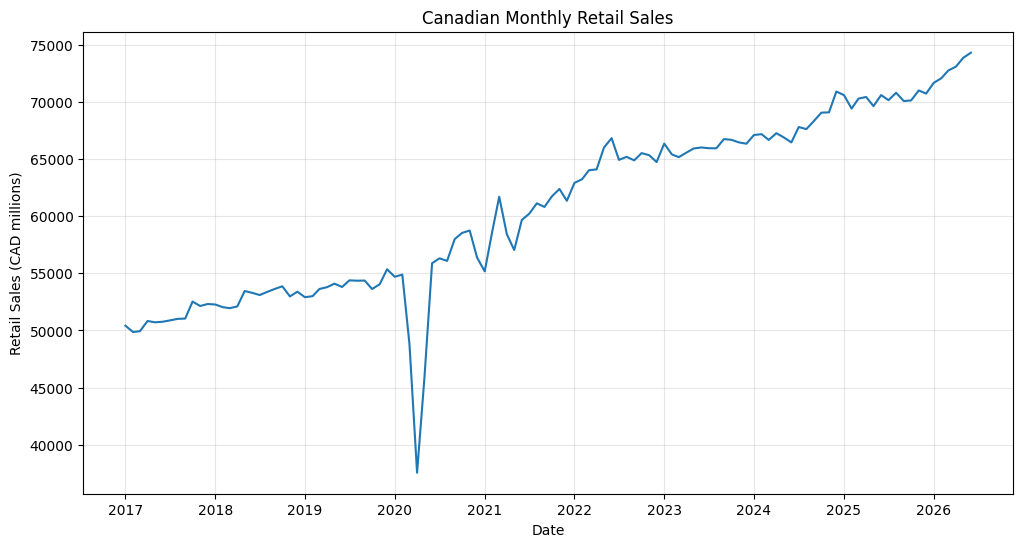

In [48]:
plt.figure(figsize=(12, 6))

plt.plot(
    retail["date"],
    retail["retail_sales"]
)

plt.title("Canadian Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Retail Sales (CAD millions)")
plt.grid(True, alpha=0.3)

plt.show()

In [49]:
retail["mom_growth"] = retail["retail_sales"].pct_change()

In [50]:
retail["yoy_growth"] = retail["retail_sales"].pct_change(12)

In [51]:
retail.tail(15)

,date,retail_sales,cpi,inflation_yoy,unemployment_rate,policy_rate,usd_cad,mom_growth,yoy_growth
99,2025-04-01,70413.0,163.1,1.746725,6.9,2.75,1.398829,0.002035,0.047065
100,2025-05-01,69613.0,163.5,1.742377,7.0,2.75,1.386010,-0.011362,0.040833
101,2025-06-01,70579.0,163.9,1.927861,6.9,2.75,1.367371,0.013877,0.062265
102,2025-07-01,70135.0,164.0,1.736973,6.9,2.75,1.369105,-0.006291,0.034638
103,2025-08-01,70780.0,164.3,1.859888,7.1,2.75,1.380200,0.009197,0.046979
104,2025-09-01,70059.0,165.0,2.357320,7.1,2.50,1.383315,-0.010186,0.025439
105,2025-10-01,70113.0,165.2,2.164502,6.9,2.25,1.399200,0.000771,0.015512
106,2025-11-01,70985.0,165.6,2.222222,6.6,2.25,1.405526,0.012437,0.027725
107,2025-12-01,70709.0,166.1,2.341343,6.8,2.25,1.380248,-0.003888,-0.002567
108,2026-01-01,71651.0,166.2,2.276923,6.5,2.25,1.377819,0.013322,0.015261


In [52]:
retail["mom_growth_pct"] = retail["mom_growth"] * 100
retail["yoy_growth_pct"] = retail["yoy_growth"] * 100

In [53]:
retail.tail(15)

,date,retail_sales,cpi,inflation_yoy,unemployment_rate,policy_rate,usd_cad,mom_growth,yoy_growth,mom_growth_pct,yoy_growth_pct
99,2025-04-01,70413.0,163.1,1.746725,6.9,2.75,1.398829,0.002035,0.047065,0.203501,4.706460
100,2025-05-01,69613.0,163.5,1.742377,7.0,2.75,1.386010,-0.011362,0.040833,-1.136154,4.083311
101,2025-06-01,70579.0,163.9,1.927861,6.9,2.75,1.367371,0.013877,0.062265,1.387672,6.226483
102,2025-07-01,70135.0,164.0,1.736973,6.9,2.75,1.369105,-0.006291,0.034638,-0.629082,3.463791
103,2025-08-01,70780.0,164.3,1.859888,7.1,2.75,1.380200,0.009197,0.046979,0.919655,4.697947
104,2025-09-01,70059.0,165.0,2.357320,7.1,2.50,1.383315,-0.010186,0.025439,-1.018649,2.543874
105,2025-10-01,70113.0,165.2,2.164502,6.9,2.25,1.399200,0.000771,0.015512,0.077078,1.551230
106,2025-11-01,70985.0,165.6,2.222222,6.6,2.25,1.405526,0.012437,0.027725,1.243707,2.772550
107,2025-12-01,70709.0,166.1,2.341343,6.8,2.25,1.380248,-0.003888,-0.002567,-0.388815,-0.256732
108,2026-01-01,71651.0,166.2,2.276923,6.5,2.25,1.377819,0.013322,0.015261,1.332221,1.526058


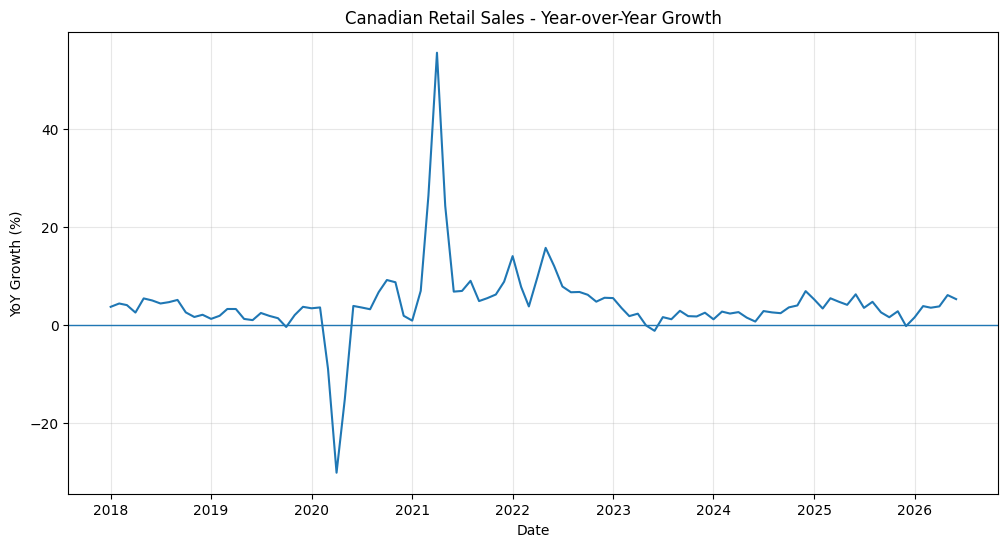

In [54]:
plt.figure(figsize=(12, 6))

plt.plot(
    retail["date"],
    retail["yoy_growth_pct"]
)

plt.axhline(0, linewidth=1)

plt.title("Canadian Retail Sales - Year-over-Year Growth")
plt.xlabel("Date")
plt.ylabel("YoY Growth (%)")
plt.grid(True, alpha=0.3)

plt.show()

In [55]:
retail[["date", "retail_sales", "cpi", "inflation_yoy"]].tail(15)

,date,retail_sales,cpi,inflation_yoy
99,2025-04-01,70413.0,163.1,1.746725
100,2025-05-01,69613.0,163.5,1.742377
101,2025-06-01,70579.0,163.9,1.927861
102,2025-07-01,70135.0,164.0,1.736973
103,2025-08-01,70780.0,164.3,1.859888
104,2025-09-01,70059.0,165.0,2.357320
105,2025-10-01,70113.0,165.2,2.164502
106,2025-11-01,70985.0,165.6,2.222222
107,2025-12-01,70709.0,166.1,2.341343
108,2026-01-01,71651.0,166.2,2.276923


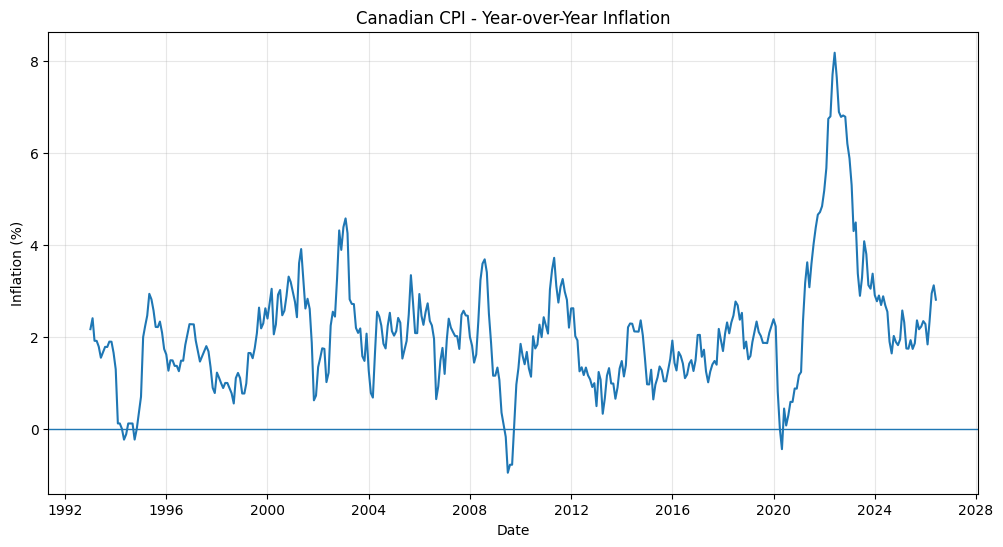

In [56]:
plt.figure(figsize=(12, 6))

plt.plot(
    cpi_clean["date"],
    cpi_clean["inflation_yoy"]
)

plt.axhline(0, linewidth=1)

plt.title("Canadian CPI - Year-over-Year Inflation")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(True, alpha=0.3)

plt.show()

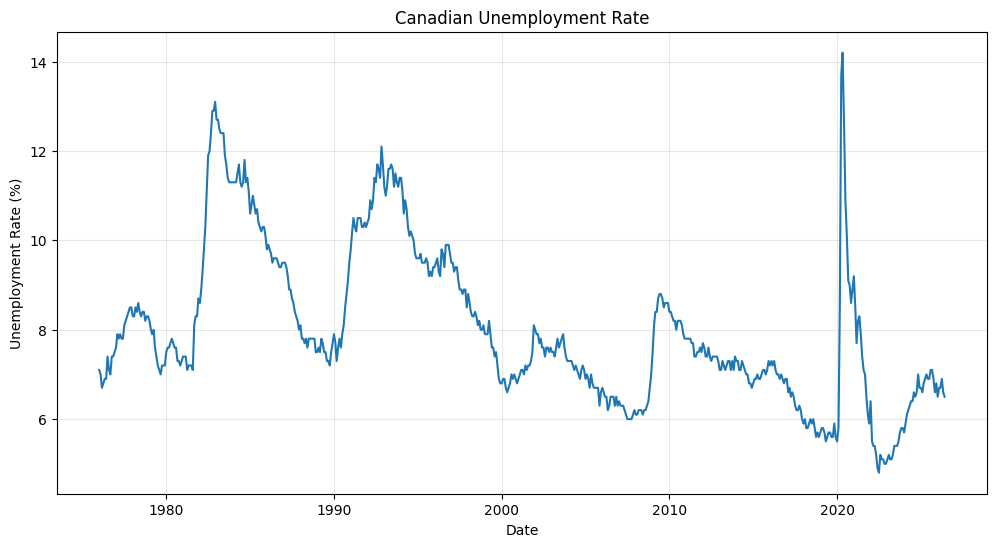

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(unemp_clean["date"], unemp_clean["unemployment_rate"])
plt.title("Canadian Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.grid(True, alpha=0.3)
plt.show()

## 5. Feature Engineering
The lag features use earlier months. The rolling averages and growth rates include the current month because the target is the following month's sales. The first few rows will have missing values because there is not enough history yet.


In [58]:
retail["sales_lag_1"] = retail["retail_sales"].shift(1)
retail["sales_lag_3"] = retail["retail_sales"].shift(3)
retail["sales_lag_6"] = retail["retail_sales"].shift(6)
retail["sales_lag_12"] = retail["retail_sales"].shift(12)

In [59]:
retail["rolling_mean_3"] = retail["retail_sales"].rolling(3).mean()
retail["rolling_mean_6"] = retail["retail_sales"].rolling(6).mean()
retail["rolling_std_6"] = retail["retail_sales"].rolling(6).std()

In [60]:
retail.isna().sum()

date                  0
retail_sales          0
cpi                   0
inflation_yoy         0
unemployment_rate     0
policy_rate           0
usd_cad               0
mom_growth            1
yoy_growth           12
mom_growth_pct        1
yoy_growth_pct       12
sales_lag_1           1
sales_lag_3           3
sales_lag_6           6
sales_lag_12         12
rolling_mean_3        2
rolling_mean_6        5
rolling_std_6         5
dtype: int64

## 6. Forecast Target and Train-Test Design
Each row uses month t to predict sales in month t+1. I used a chronological split instead of shuffling the rows. The models are fitted once on the training period, then use the observed features for each test month.

The split is based on the **feature month**: training ends in December 2024, and test feature months run from January 2025 to May 2026. The 17 sales months being predicted are February 2025 to June 2026. The last training target is January 2025, so it does not overlap the test targets.

This is a retrospective comparison. It assumes each row's current-month data are available; retail and macroeconomic publication lags were not fully modeled. It should not be read as a real-time forecast backtest.


In [61]:
retail["target_next_month"] = (
    retail["retail_sales"].shift(-1)
)

In [62]:
retail[
    ["date", "retail_sales", "target_next_month"]
].tail()

,date,retail_sales,target_next_month
109,2026-02-01,72054.0,72726.0
110,2026-03-01,72726.0,73065.0
111,2026-04-01,73065.0,73839.0
112,2026-05-01,73839.0,74283.0
113,2026-06-01,74283.0,NaN


In [63]:
history_features = [
    "retail_sales",
    "mom_growth_pct",
    "yoy_growth_pct",
    "sales_lag_1",
    "sales_lag_3",
    "sales_lag_6",
    "sales_lag_12",
    "rolling_mean_3",
    "rolling_mean_6",
    "rolling_std_6"
]

In [64]:
macro_features = history_features + [
    "inflation_yoy",
    "unemployment_rate",
    "policy_rate",
    "usd_cad"
]

In [65]:
model_df = retail[
    ["date", "target_next_month"] + macro_features
].dropna().copy()

In [66]:
model_df.shape

(101, 16)

In [67]:
model_df.head()
model_df.tail()

,date,target_next_month,retail_sales,mom_growth_pct,yoy_growth_pct,sales_lag_1,sales_lag_3,sales_lag_6,sales_lag_12,rolling_mean_3,rolling_mean_6,rolling_std_6,inflation_yoy,unemployment_rate,policy_rate,usd_cad
108,2026-01-01,72054.0,71651.0,1.332221,1.526058,70709.0,70113.0,70135.0,70574.0,71115.000000,70716.166667,590.929578,2.276923,6.5,2.25,1.377819
109,2026-02-01,72726.0,72054.0,0.562449,3.824207,71651.0,70985.0,70780.0,69400.0,71471.333333,70928.500000,807.613707,1.834862,6.7,2.25,1.365074
110,2026-03-01,73065.0,72726.0,0.932634,3.495090,72054.0,70709.0,70059.0,70270.0,72143.666667,71373.000000,954.011950,2.324159,6.7,2.25,1.371709
111,2026-04-01,73839.0,73065.0,0.466133,3.766350,72726.0,71651.0,70113.0,70413.0,72615.000000,71865.000000,935.261888,2.942980,6.9,2.25,1.375057
112,2026-05-01,74283.0,73839.0,1.059331,6.070705,73065.0,72054.0,70985.0,69613.0,73210.000000,72340.666667,1107.997954,3.119266,6.6,2.25,1.372305


In [68]:
train = model_df[
    model_df["date"] < "2025-01-01"
].copy()

test = model_df[
    model_df["date"] >= "2025-01-01"
].copy()

In [69]:
print(train.shape)
print(test.shape)

print(train["date"].min(), train["date"].max())
print(test["date"].min(), test["date"].max())

(84, 16)
(17, 16)
2018-01-01 00:00:00 2024-12-01 00:00:00
2025-01-01 00:00:00 2026-05-01 00:00:00


In [70]:
assert retail["date"].is_unique
assert retail["date"].is_monotonic_increasing
assert retail["date"].tolist() == pd.date_range(retail["date"].min(), retail["date"].max(), freq="MS").tolist()
assert not train.empty and not test.empty
assert train["date"].max() < test["date"].min()
retail.to_csv(PROCESSED / "retail_model_dataset.csv", index=False)


## 7. Naive Baseline
The baseline predicts that next month's sales will equal this month's sales. This gives the other models a simple benchmark to beat.


In [71]:
test["baseline_prediction"] = test["retail_sales"]

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [73]:
baseline_mae = mean_absolute_error(
    test["target_next_month"],
    test["baseline_prediction"]
)

In [74]:
baseline_rmse = np.sqrt(
    mean_squared_error(
        test["target_next_month"],
        test["baseline_prediction"]
    )
)

In [75]:
print("Baseline MAE:", baseline_mae)
print("Baseline RMSE:", baseline_rmse)

Baseline MAE: 619.9411764705883
Baseline RMSE: 690.85407499788


## 8. Linear and Ridge Regression
I first tested ordinary linear regression with sales-history features, then added the macro variables. The results below show whether either version improves on the baseline.


In [76]:
from sklearn.linear_model import LinearRegression

In [77]:
X_train_history = train[history_features]
X_test_history = test[history_features]

y_train = train["target_next_month"]
y_test = test["target_next_month"]

In [78]:
lr_history = LinearRegression()

lr_history.fit(
    X_train_history,
    y_train
)

pred_lr_history = lr_history.predict(
    X_test_history
)

In [79]:
lr_history_mae = mean_absolute_error(
    y_test,
    pred_lr_history
)

lr_history_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr_history
    )
)

lr_history_r2 = r2_score(
    y_test,
    pred_lr_history
)

print("History-only Linear Regression")
print("MAE:", lr_history_mae)
print("RMSE:", lr_history_rmse)
print("R²:", lr_history_r2)

History-only Linear Regression
MAE: 737.1076721253904
RMSE: 871.9650785318756
R²: 0.629793433580625


In [80]:
X_train_macro = train[macro_features]
X_test_macro = test[macro_features]

In [81]:
lr_macro = LinearRegression()

lr_macro.fit(
    X_train_macro,
    y_train
)

pred_lr_macro = lr_macro.predict(
    X_test_macro
)

In [82]:
# Baseline
baseline_r2 = r2_score(
    y_test,
    test["baseline_prediction"]
)

# Linear Regression - History + Macro
lr_macro_mae = mean_absolute_error(
    y_test,
    pred_lr_macro
)

lr_macro_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_lr_macro
    )
)

lr_macro_r2 = r2_score(
    y_test,
    pred_lr_macro
)

results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression - History Only",
        "Linear Regression - History + Macro"
    ],
    "MAE": [
        baseline_mae,
        lr_history_mae,
        lr_macro_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_history_rmse,
        lr_macro_rmse
    ],
    "R²": [
        baseline_r2,
        lr_history_r2,
        lr_macro_r2
    ]
})

results = results.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 3
})

print(results.to_string(index=False))

                              Model     MAE    RMSE     R²
                     Naive Baseline  619.94  690.85  0.768
   Linear Regression - History Only  737.11  871.97  0.630
Linear Regression - History + Macro 1751.62 1904.35 -0.766


In [83]:
coef_history = pd.DataFrame({
    "Feature": history_features,
    "Coefficient": lr_history.coef_
})

print(
    coef_history
    .sort_values("Coefficient", key=abs, ascending=False)
    .to_string(index=False)
)

       Feature  Coefficient
mom_growth_pct  -371.989033
yoy_growth_pct    25.026821
   sales_lag_1    -2.168287
rolling_mean_3     1.505948
  retail_sales     1.215201
rolling_mean_6     0.665498
 rolling_std_6     0.480669
   sales_lag_3    -0.284815
  sales_lag_12     0.062054
   sales_lag_6     0.039869


In [84]:
coef_macro = pd.DataFrame({
    "Feature": macro_features,
    "Coefficient": lr_macro.coef_
})

print(
    coef_macro
    .sort_values("Coefficient", key=abs, ascending=False)
    .to_string(index=False)
)

          Feature   Coefficient
          usd_cad -19238.175877
      policy_rate    511.506480
   mom_growth_pct   -324.653826
unemployment_rate    273.944084
    inflation_yoy    122.366728
   yoy_growth_pct     18.101722
      sales_lag_1     -1.989178
   rolling_mean_3      1.423922
     retail_sales      1.091290
   rolling_mean_6      0.626340
    rolling_std_6      0.461124
      sales_lag_3     -0.304086
     sales_lag_12      0.124604
      sales_lag_6      0.009170


The linear models did not beat the baseline. Several lag and rolling features describe similar sales patterns, so I tried Ridge to shrink the coefficients. That is a possible explanation to investigate, not proof that multicollinearity caused the errors. The coefficient tables above use different units, so their magnitudes are not directly comparable measures of importance.

The pipeline fits the scaler on the training data and applies the same scaling to the test data before Ridge makes predictions.


In [85]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

ridge_history = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_history.fit(X_train_history, y_train)

pred_ridge_history = ridge_history.predict(X_test_history)

In [86]:
ridge_history_mae = mean_absolute_error(
    y_test,
    pred_ridge_history
)

ridge_history_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_ridge_history
    )
)

ridge_history_r2 = r2_score(
    y_test,
    pred_ridge_history
)

print("Ridge - History Only")
print("MAE:", ridge_history_mae)
print("RMSE:", ridge_history_rmse)
print("R²:", ridge_history_r2)

Ridge - History Only
MAE: 537.1007051595208
RMSE: 638.1589248150252
R²: 0.8017087146163338


In [87]:
ridge_macro = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_macro.fit(X_train_macro, y_train)

pred_ridge_macro = ridge_macro.predict(X_test_macro)

In [88]:
ridge_macro_mae = mean_absolute_error(
    y_test,
    pred_ridge_macro
)

ridge_macro_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        pred_ridge_macro
    )
)

ridge_macro_r2 = r2_score(
    y_test,
    pred_ridge_macro
)

print("Ridge - History + Macro")
print("MAE:", ridge_macro_mae)
print("RMSE:", ridge_macro_rmse)
print("R²:", ridge_macro_r2)

Ridge - History + Macro
MAE: 1460.1452068606072
RMSE: 1585.6194096964816
R²: -0.2241759415446818


In [89]:
results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression - History",
        "Linear Regression - History + Macro",
        "Ridge - History",
        "Ridge - History + Macro"
    ],
    "MAE": [
        baseline_mae,
        lr_history_mae,
        lr_macro_mae,
        ridge_history_mae,
        ridge_macro_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_history_rmse,
        lr_macro_rmse,
        ridge_history_rmse,
        ridge_macro_rmse
    ],
    "R²": [
        baseline_r2,
        lr_history_r2,
        lr_macro_r2,
        ridge_history_r2,
        ridge_macro_r2
    ]
})

print(
    results
    .round({"MAE": 2, "RMSE": 2, "R²": 3})
    .to_string(index=False)
)

                              Model     MAE    RMSE     R²
                     Naive Baseline  619.94  690.85  0.768
        Linear Regression - History  737.11  871.97  0.630
Linear Regression - History + Macro 1751.62 1904.35 -0.766
                    Ridge - History  537.10  638.16  0.802
            Ridge - History + Macro 1460.15 1585.62 -0.224


## 9. Random Forest
Next I tried Random Forest to allow for nonlinear relationships. I kept the settings simple: 300 trees and a maximum depth of 5. I did not carry out an extensive parameter search.


In [90]:
from sklearn.ensemble import RandomForestRegressor

rf_history = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=5
)

rf_history.fit(X_train_history, y_train)
pred_rf_history = rf_history.predict(X_test_history)

rf_history_mae = mean_absolute_error(y_test, pred_rf_history)
rf_history_rmse = np.sqrt(mean_squared_error(y_test, pred_rf_history))
rf_history_r2 = r2_score(y_test, pred_rf_history)

print("Random Forest - History")
print("MAE:", rf_history_mae)
print("RMSE:", rf_history_rmse)
print("R²:", rf_history_r2)

Random Forest - History
MAE: 1384.2510718954204
RMSE: 1873.9908580686183
R²: -0.7099399900550607


In [91]:
rf_macro = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    max_depth=5
)

rf_macro.fit(X_train_macro, y_train)
pred_rf_macro = rf_macro.predict(X_test_macro)

rf_macro_mae = mean_absolute_error(y_test, pred_rf_macro)
rf_macro_rmse = np.sqrt(mean_squared_error(y_test, pred_rf_macro))
rf_macro_r2 = r2_score(y_test, pred_rf_macro)

print("Random Forest - History + Macro")
print("MAE:", rf_macro_mae)
print("RMSE:", rf_macro_rmse)
print("R²:", rf_macro_r2)

Random Forest - History + Macro
MAE: 1595.4516956937398
RMSE: 2169.9961931339503
R²: -1.2927878796713483


In [92]:
print("Training target range:")
print(y_train.min(), y_train.max())

print("\nTest target range:")
print(y_test.min(), y_test.max())

print("\nRandom Forest prediction range:")
print(pred_rf_history.min(), pred_rf_history.max())

Training target range:
37562.0 70891.0

Test target range:
69400.0 74283.0

Random Forest prediction range:
69764.91211111112 70261.96283333334


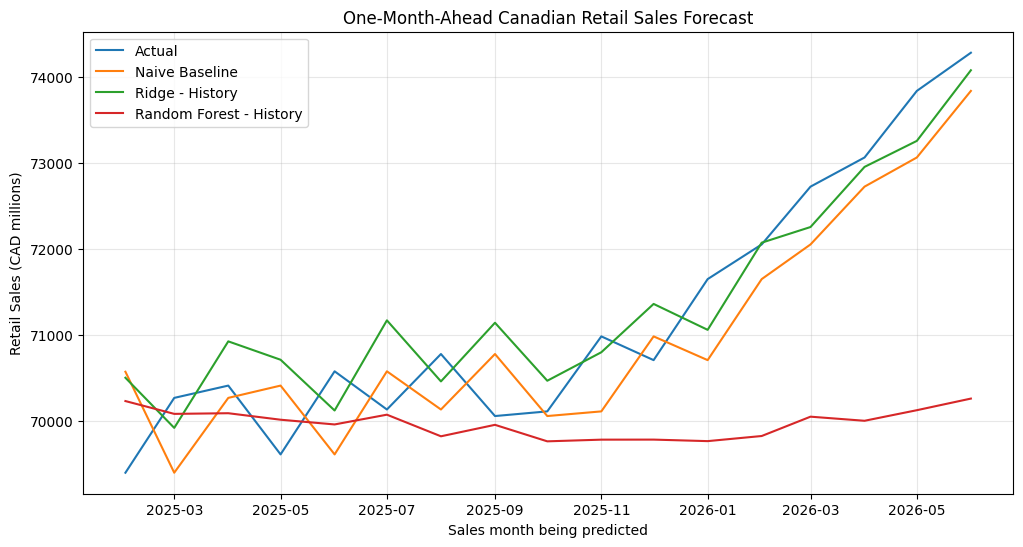

In [93]:
# Plot predictions against the month they refer to.
forecast_dates = test["date"] + pd.DateOffset(months=1)

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_dates,
    y_test,
    label="Actual"
)

plt.plot(
    forecast_dates,
    test["baseline_prediction"],
    label="Naive Baseline"
)

plt.plot(
    forecast_dates,
    pred_ridge_history,
    label="Ridge - History"
)

plt.plot(
    forecast_dates,
    pred_rf_history,
    label="Random Forest - History"
)

plt.title("One-Month-Ahead Canadian Retail Sales Forecast")
plt.xlabel("Sales month being predicted")
plt.ylabel("Retail Sales (CAD millions)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 10. Growth-Target Experiment
The sales-level Random Forest did poorly. The range check above shows that some test sales were above the training maximum, while the predictions stayed in a narrow range. A regression forest averages training outcomes in its leaves, so it cannot extrapolate above the largest training target.

I then tried predicting next-month growth and converting it back to sales with `current_sales * (1 + predicted_growth)`. I also used a smaller history feature set: MoM growth, YoY growth, and six-month sales volatility. Because both the target and the features changed, this comparison does not isolate the effect of changing the target alone.


In [94]:
retail["target_growth_next_month"] = (
    retail["target_next_month"] / retail["retail_sales"] - 1
)

In [95]:
growth_features_history = [
    "mom_growth_pct",
    "yoy_growth_pct",
    "rolling_std_6"
]

growth_features_macro = growth_features_history + [
    "inflation_yoy",
    "unemployment_rate",
    "policy_rate",
    "usd_cad"
]

In [96]:
growth_df = retail[
    [
        "date",
        "retail_sales",
        "target_growth_next_month"
    ]
    + growth_features_macro
].dropna().copy()

In [97]:
growth_train = growth_df[
    growth_df["date"] < "2025-01-01"
].copy()

growth_test = growth_df[
    growth_df["date"] >= "2025-01-01"
].copy()

In [98]:
X_train_growth_history = growth_train[growth_features_history]
X_test_growth_history = growth_test[growth_features_history]

y_train_growth = growth_train["target_growth_next_month"]
y_test_growth = growth_test["target_growth_next_month"]

rf_growth_history = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf_growth_history.fit(
    X_train_growth_history,
    y_train_growth
)

pred_growth_history = rf_growth_history.predict(
    X_test_growth_history
)

In [99]:
pred_sales_growth_history = (
    growth_test["retail_sales"]
    * (1 + pred_growth_history)
)

In [100]:
actual_next_sales = (
    growth_test["retail_sales"]
    * (1 + y_test_growth)
)

In [101]:
rf_growth_history_mae = mean_absolute_error(
    actual_next_sales,
    pred_sales_growth_history
)

rf_growth_history_rmse = np.sqrt(
    mean_squared_error(
        actual_next_sales,
        pred_sales_growth_history
    )
)

rf_growth_history_r2 = r2_score(
    actual_next_sales,
    pred_sales_growth_history
)

print("Random Forest - Growth Target - History")
print("MAE:", rf_growth_history_mae)
print("RMSE:", rf_growth_history_rmse)
print("R²:", rf_growth_history_r2)

Random Forest - Growth Target - History
MAE: 589.3608288300517
RMSE: 666.6482774105423
R²: 0.7836088694880674


In [102]:
X_train_growth_macro = growth_train[growth_features_macro]
X_test_growth_macro = growth_test[growth_features_macro]

rf_growth_macro = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf_growth_macro.fit(
    X_train_growth_macro,
    y_train_growth
)

pred_growth_macro = rf_growth_macro.predict(
    X_test_growth_macro
)

pred_sales_growth_macro = (
    growth_test["retail_sales"]
    * (1 + pred_growth_macro)
)

In [103]:
rf_growth_macro_mae = mean_absolute_error(
    actual_next_sales,
    pred_sales_growth_macro
)

rf_growth_macro_rmse = np.sqrt(
    mean_squared_error(
        actual_next_sales,
        pred_sales_growth_macro
    )
)

rf_growth_macro_r2 = r2_score(
    actual_next_sales,
    pred_sales_growth_macro
)

print("Random Forest - Growth Target - History + Macro")
print("MAE:", rf_growth_macro_mae)
print("RMSE:", rf_growth_macro_rmse)
print("R²:", rf_growth_macro_r2)

Random Forest - Growth Target - History + Macro
MAE: 618.1145904444463
RMSE: 723.2526243671691
R²: 0.7453017448839552


## 11. Model Comparison
The table compares errors on the same 17 target months. MAE and RMSE are in CAD millions; lower is better. RMSE puts more weight on large errors. R² compares predictions with the test-period mean; a negative value means the model performed worse than that mean benchmark, not necessarily worse than the naive forecast.


In [104]:
final_results = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression - History",
        "Ridge - History",
        "Random Forest - Level",
        "Random Forest - Growth Target",
        "Random Forest - Growth + Macro"
    ],
    "MAE": [
        baseline_mae,
        lr_history_mae,
        ridge_history_mae,
        rf_history_mae,
        rf_growth_history_mae,
        rf_growth_macro_mae
    ],
    "RMSE": [
        baseline_rmse,
        lr_history_rmse,
        ridge_history_rmse,
        rf_history_rmse,
        rf_growth_history_rmse,
        rf_growth_macro_rmse
    ],
    "R2": [
        baseline_r2,
        lr_history_r2,
        ridge_history_r2,
        rf_history_r2,
        rf_growth_history_r2,
        rf_growth_macro_r2
    ]
})

final_results = final_results.sort_values("MAE")

print(
    final_results
    .round({"MAE": 2, "RMSE": 2, "R2": 3})
    .to_string(index=False)
)

                         Model     MAE    RMSE     R2
               Ridge - History  537.10  638.16  0.802
 Random Forest - Growth Target  589.36  666.65  0.784
Random Forest - Growth + Macro  618.11  723.25  0.745
                Naive Baseline  619.94  690.85  0.768
   Linear Regression - History  737.11  871.97  0.630
         Random Forest - Level 1384.25 1873.99 -0.710


In [105]:
ridge_improvement = (
    (baseline_mae - ridge_history_mae)
    / baseline_mae
    * 100
)

print(f"Ridge MAE improvement vs baseline: {ridge_improvement:.1f}%")

Ridge MAE improvement vs baseline: 13.4%


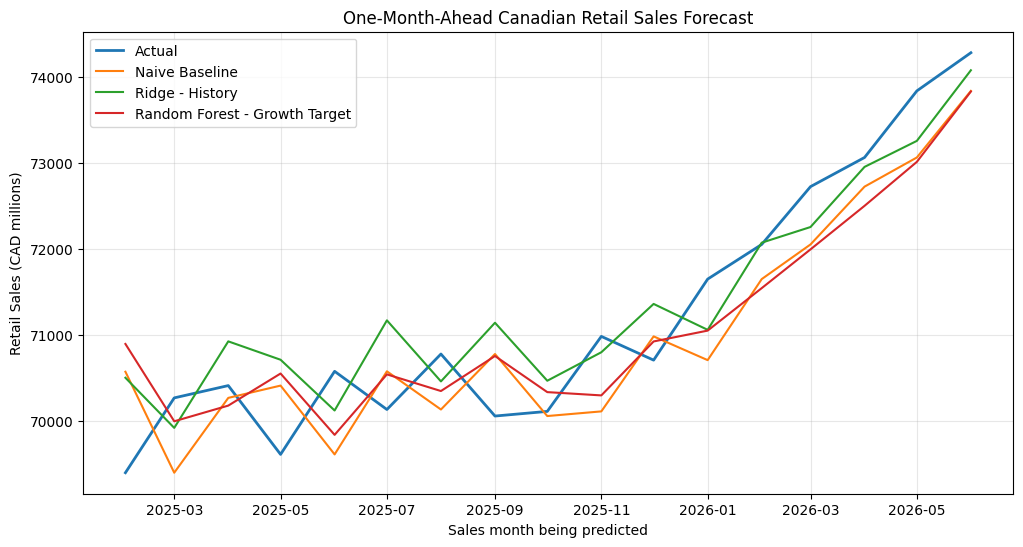

In [106]:
growth_forecast_dates = growth_test["date"] + pd.DateOffset(months=1)

plt.figure(figsize=(12, 6))

plt.plot(
    forecast_dates,
    y_test,
    label="Actual",
    linewidth=2
)

plt.plot(
    forecast_dates,
    test["baseline_prediction"],
    label="Naive Baseline"
)

plt.plot(
    forecast_dates,
    pred_ridge_history,
    label="Ridge - History"
)

plt.plot(
    growth_forecast_dates,
    pred_sales_growth_history,
    label="Random Forest - Growth Target"
)

plt.title("One-Month-Ahead Canadian Retail Sales Forecast")
plt.xlabel("Sales month being predicted")
plt.ylabel("Retail Sales (CAD millions)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## 12. Conclusions and Limitations


### Conclusions

- **Naive baseline:** Using this month's sales for next month was a strong benchmark, with MAE of about CAD 620M.
- **Linear Regression:** The history-only model did worse than the baseline. The lag and rolling features overlap, which raised a concern about multicollinearity. This alone does not prove why the model performed poorly.
- **Ridge:** I tested regularization next. History-only Ridge had the lowest MAE among the models tested: CAD 537.10M versus CAD 619.94M for the baseline, a 13.4% reduction in this test period.
- **Random Forest, sales level:** MAE was about CAD 1,384M. Its narrow prediction range was consistent with the difficulty of predicting sales above the training range.
- **Random Forest, growth target:** Predicting growth with the smaller feature set reduced MAE to about CAD 589M. This was a useful improvement, but Ridge still performed better. Both the target and the features changed in this experiment.
- **Macro variables:** Adding the selected inflation, unemployment, policy-rate, and exchange-rate features did not improve the matching models in this test period. That does not mean these variables are never useful.

The main lesson for me was that a more complicated model does not automatically give a better forecast. The baseline and the unsuccessful models helped me understand the results.

### Limitations

- There are 84 training rows and only 17 test rows after creating the features, so the comparison is based on a small sample.
- The COVID period is a major shock in the data.
- Retail and macroeconomic publication lags were not fully modeled. The data include historical revisions, rather than only values available at each forecast date.
- I tried only a few models and settings. I also used the same test period to compare and diagnose the models, so it is not an untouched final evaluation set.
- Macro variables may act with a delay; this project mainly uses same-month values.
- The analysis uses total Canadian retail sales. Results could differ for individual industries or categories.
- This is a self-directed learning project, not a production forecasting system. The findings are limited to this dataset and test period.
